In [17]:
# Imports
import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.models import resnet50
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

In [18]:
# Function
def preprocess_frame(frame):
        preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
                             ])
        return preprocess(frame)

In [19]:
# Model
num_classes = 1081
resnet_checkpoint_path = 'models/resnet50_weights_best_acc.tar'

model = resnet50(num_classes=num_classes)
checkpoint = torch.load(resnet_checkpoint_path, map_location='cpu')
state_dict = checkpoint["model"]

model = resnet50(num_classes=num_classes)
model.load_state_dict(state_dict=state_dict, strict=True)
model = torch.nn.Sequential(*(list(model.children())[:-1]))
model.eval()

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [20]:
# # Create datasets
# video_path = "data/videos/grass_long.mp4"
# image_path = "data/frames/grass_long2/"

# amount_of_frames = 100
# video = cv2.VideoCapture(video_path)
# frame_count = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
# frame_interval = int(frame_count/(amount_of_frames-1)) # -1 since frames start at 0
# print(frame_interval)

# # frame_interval = 321

# current_frame = 0

# video = cv2.VideoCapture(video_path)

# while True:
#     read, frame = video.read()
#     if not read:
#         break
#     if current_frame % frame_interval == 0:
#         img_name = os.path.join(image_path, f"frame_b2_{current_frame:04d}.jpg")
#         cv2.imwrite(img_name, frame)
#         print(f"Saved frame {current_frame}")
#     current_frame += 1

# video.release()

In [21]:
# Datasets
dataset_1 = "data/frames/biodiverse_1/"
frames_1 = os.listdir(dataset_1)

dataset_2 = "data/frames/biodiverse_2/"
frames_2 = os.listdir(dataset_2)

In [22]:
# Embeddings
embeddings1 = []
for frame in frames_1:
    img = Image.open(dataset_1 + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings1.append(features.cpu().numpy().flatten())
embeddingspace1 = np.array(embeddings1)

embeddings2 = []
for frame in frames_2:
    img = Image.open(dataset_2 + frame)
    preprocessed_img = preprocess_frame(img)
    input_tensor = preprocessed_img.unsqueeze(0)
    with torch.no_grad():
        features = model(input_tensor)
    embeddings2.append(features.cpu().numpy().flatten())
embeddingspace2 = np.array(embeddings2)

In [23]:
# Density calculation
k = 50

nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace1)
distances, indices = nbrs.kneighbors(embeddingspace1)
distances = distances[:, 1:] # remove distance to self
density = 1 / (np.mean(distances, axis=1) + 1e-10)
average_density1 = np.mean(density)

centre = embeddingspace1.mean(axis=0)
euclidean_distances = np.linalg.norm(embeddingspace1 - centre, axis=1)
threshold_eucl_rms1 = np.sqrt((euclidean_distances**2).mean())
threshold_eucl_med1 = np.median(euclidean_distances)

distances = pairwise_distances(embeddingspace1, metric='cosine')
upper_distances = distances[np.triu_indices_from(distances, k=1)]
mean_distance = upper_distances.mean()
global_mean_density1 = 1 / (mean_distance + 1e-12)
median_distance = np.median(upper_distances)
global_median_density1 = 1 / (median_distance + 1e-12)

nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace2)
distances, indices = nbrs.kneighbors(embeddingspace2)
distances = distances[:, 1:] # remove distance to self
density = 1 / (np.mean(distances, axis=1) + 1e-10)
average_density2 = np.mean(density)

centre = embeddingspace2.mean(axis=0)
euclidean_distances = np.linalg.norm(embeddingspace2 - centre, axis=1)
threshold_eucl_rms2 = np.sqrt((euclidean_distances**2).mean())
threshold_eucl_med2 = np.median(euclidean_distances)

distances = pairwise_distances(embeddingspace2, metric='cosine')
upper_distances = distances[np.triu_indices_from(distances, k=1)]
mean_distance = upper_distances.mean()
global_mean_density2 = 1 / (mean_distance + 1e-12)
median_distance = np.median(upper_distances)
global_median_density2 = 1 / (median_distance + 1e-12)

print("Average kNN (k = 10) density of initial embedding space: ", average_density1)
print("Average kNN (k = 10) density of new dataset: ", average_density2)

print("Average Norm distance of initial embedding space: ", threshold_eucl_rms1)
print("Average Norm distance of new dataset: ", threshold_eucl_rms2)

print("Median Norm distance of initial embedding space: ", threshold_eucl_med1)
print("Median Norm distance of new dataset: ", threshold_eucl_med2)

print("Average global density of initial embedding space: ", global_mean_density1)
print("Average global density of new dataset: ", global_mean_density2)

print("Median global density of initial embedding space: ", global_median_density1)
print("Median global density of new dataset: ", global_median_density2)

Average kNN (k = 10) density of initial embedding space:  5.007363
Average kNN (k = 10) density of new dataset:  4.58782
Average Norm distance of initial embedding space:  11.301735
Average Norm distance of new dataset:  11.448028
Median Norm distance of initial embedding space:  10.676353
Median Norm distance of new dataset:  11.007283
Average global density of initial embedding space:  3.5121305841657176
Average global density of new dataset:  3.320472974760573
Median global density of initial embedding space:  3.636046350582785
Median global density of new dataset:  3.4185426604144595


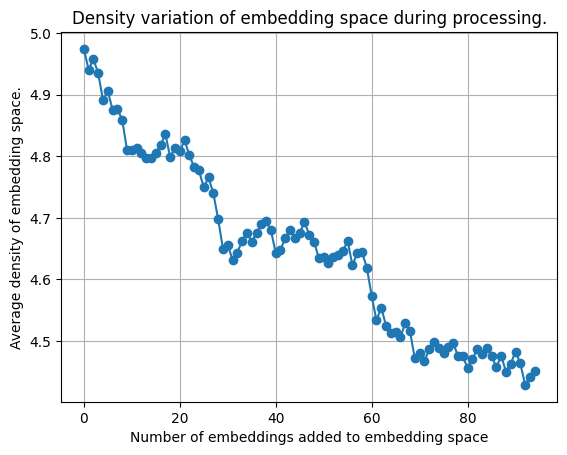

Embeddings added:  58
Embeddings removed:  74
Embeddings mowed:  37
Embeddigns in space:  121
Average density after processing:  4.4512577


In [24]:
# Algorithm
threshold = average_density1
all_densities = []

mow_count = 0
emb_count = 0
add_count = 0

for e in embeddings2:
    embeddings1.append(e)
    embeddingspace = np.array(embeddings1)
    new_point = embeddingspace[-1]

    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace)
    distances, indices = nbrs.kneighbors([new_point])
    distances = distances[:, 1:] # Remove distance to self
    indices = indices[:, 1:] # Remove distance to self
    avg_distance = np.mean(distances)
    point_density = 1 / (avg_distance + 1e-10)
    
    if (point_density >= threshold):
        closest_idx = indices[0, 0]
        del embeddings1[closest_idx]
        del embeddings1[-1]
        mow_count += 1
        emb_count += 2
    else:
        add_count += 1
    
    embeddingspace = np.array(embeddings1)
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto', metric='cosine').fit(embeddingspace)
    distances, indices = nbrs.kneighbors(embeddingspace)
    distances = distances[:, 1:] # remove distance to self
    density = 1 / (np.mean(distances, axis=1) + 1e-10)
    average_density = np.mean(density)
    all_densities.append(average_density)

plt.plot(range(0, len(embeddings2)), all_densities, marker='o')
plt.xlabel("Number of embeddings added to embedding space")
plt.ylabel("Average density of embedding space.")
plt.title("Density variation of embedding space during processing.")
plt.grid(True)
plt.show()

print("Embeddings added: ", add_count)
print("Embeddings removed: ", emb_count)
print("Embeddings mowed: ", mow_count)
print("Embeddigns in space: ", len(embeddings1))

print("Average density after processing: ", average_density)